In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
from huggingface_hub import HfApi, hf_hub_download, login


# Defining Model Architecture

In [2]:
# ============================================================
# ARCHITECTURE — UNet
# ============================================================
class DoubleConv(nn.Module):
    '''
    Two consecutive Conv2d → GroupNorm → SiLU blocks.
    Standard UNet building block.
    '''
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=max(1, out_ch // 8), num_channels=out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=max(1, out_ch // 8), num_channels=out_ch),
            nn.SiLU(),
        )
    def forward(self, x):
        return self.block(x)



In [3]:
class DownBlock(nn.Module):
    '''DoubleConv → MaxPool2d. Returns both pre-pool (skip) and pooled.'''
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skip = self.conv(x)   # full resolution — saved for skip connection
        down = self.pool(skip)
        return skip, down



In [4]:

class UpBlock(nn.Module):
    '''
    ConvTranspose2d upsampling → concat skip → DoubleConv.
    Recovers spatial detail lost during downsampling.
    '''
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Handle any size mismatch from odd spatial dims
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)



In [5]:

class SindhUNet(nn.Module):
    '''
    UNet for DSI estimation from 33 satellite channels.

    Architecture:
        Input  (B, 33, 64, 64)
        Enc1   (B, 64,  64, 64)  + skip s1
        Enc2   (B, 128, 32, 32)  + skip s2
        Enc3   (B, 256, 16, 16)  + skip s3
        Enc4   (B, 512,  8,  8)  + skip s4
        Bot    (B, 512,  4,  4)
        Dec4   (B, 256,  8,  8)  + s4
        Dec3   (B, 128, 16, 16)  + s3
        Dec2   (B,  64, 32, 32)  + s2
        Dec1   (B,  32, 64, 64)  + s1
        Head   (B,   1, 64, 64)  sigmoid → DSI in [0,1]

    Parameters: ~7.7M (well within T4 memory budget)
    '''

    def __init__(self, in_channels=33, base_ch=64):
        super().__init__()

        # --- Encoder ---
        self.enc1 = DownBlock(in_channels, base_ch)        # 64  → 32
        self.enc2 = DownBlock(base_ch,     base_ch * 2)    # 32  → 16
        self.enc3 = DownBlock(base_ch * 2, base_ch * 4)    # 16  →  8
        self.enc4 = DownBlock(base_ch * 4, base_ch * 8)    #  8  →  4

        # --- Bottleneck ---
        self.bottleneck = DoubleConv(base_ch * 8, base_ch * 8)

        # --- Decoder ---
        self.dec4 = UpBlock(base_ch * 8, base_ch * 8, base_ch * 4)
        self.dec3 = UpBlock(base_ch * 4, base_ch * 4, base_ch * 2)
        self.dec2 = UpBlock(base_ch * 2, base_ch * 2, base_ch)
        self.dec1 = UpBlock(base_ch,     base_ch,     base_ch // 2)

        # --- Output head ---
        self.head = nn.Sequential(
            nn.Conv2d(base_ch // 2, 1, kernel_size=1),
            nn.Sigmoid()   # DSI is in [0, 1] by construction
        )

    def forward(self, x):
        '''
        x: (B, 33, 64, 64)
        Returns: (B, 1, 64, 64)  DSI prediction in [0, 1]
        '''
        # Encoder
        s1, x = self.enc1(x)   # s1: (B, 64, 64, 64),  x: (B, 64, 32, 32)
        s2, x = self.enc2(x)   # s2: (B,128, 32, 32),  x: (B,128, 16, 16)
        s3, x = self.enc3(x)   # s3: (B,256, 16, 16),  x: (B,256,  8,  8)
        s4, x = self.enc4(x)   # s4: (B,512,  8,  8),  x: (B,512,  4,  4)

        # Bottleneck
        x = self.bottleneck(x)  # (B, 512, 4, 4)

        # Decoder
        x = self.dec4(x, s4)   # (B, 256,  8,  8)
        x = self.dec3(x, s3)   # (B, 128, 16, 16)
        x = self.dec2(x, s2)   # (B,  64, 32, 32)
        x = self.dec1(x, s1)   # (B,  32, 64, 64)

        # Head
        return self.head(x)    # (B, 1, 64, 64)


# Defining Dataset

In [6]:


# ============================================================
# DATASET
# ============================================================

class SindhUNetDataset(Dataset):
    '''
    Dataset for Model A (UNet DSI estimator).

    Each .pt file shape: (96, 38, 64, 64)
      - 96 months (Jan 2016 – Dec 2023)
      - 38 channels
      - 64×64 spatial

    For each patch, every month is a separate sample:
      Input:  channels 0-32  → (33, 64, 64)   satellite observations
      Target: channel  37    → ( 1, 64, 64)   DSI map

    Total samples:
      Train: 400 patches × 96 months = 38,400
      Val:   100 patches × 96 months =  9,600
    '''

    def __init__(self, data_dir, total_months=96):
        self.data_dir     = data_dir
        self.total_months = total_months
        self.files        = sorted([
            f for f in os.listdir(data_dir) if f.endswith('.pt')
        ])
        self.total_samples = len(self.files) * total_months

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        patch_idx = idx // self.total_months
        month_idx = idx  % self.total_months

        patch = torch.load(
            os.path.join(self.data_dir, self.files[patch_idx]),
            weights_only=True,
            mmap=True
        )
        # patch: (96, 38, 64, 64)

        # Input: all 33 satellite channels for this month
        X = patch[month_idx, :33, :, :]   # (33, 64, 64)

        # Target: DSI (channel 37) for this month
        y = patch[month_idx, 37, :, :]    # (64, 64)

        return X, y


class SindhUNetTestDataset(Dataset):
    '''
    Test dataset for Model A.

    Each .pt file shape: (26, 38, 64, 64)
      - 26 months (Jan 2024 – Feb 2026)
      - New spatial locations never seen during training

    Every month is a separate sample.
    Total: 500 patches × 26 months = 13,000 samples
    '''

    def __init__(self, data_dir, total_months=26):
        self.data_dir     = data_dir
        self.total_months = total_months
        self.files        = sorted([
            f for f in os.listdir(data_dir) if f.endswith('.pt')
        ])
        self.total_samples = len(self.files) * total_months

        print(f"  Patches       : {len(self.files)}")
        print(f"  Months/patch  : {self.total_months}")
        print(f"  Total samples : {self.total_samples}")

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        patch_idx = idx // self.total_months
        month_idx = idx  % self.total_months

        patch = torch.load(
            os.path.join(self.data_dir, self.files[patch_idx]),
            weights_only=True,
            mmap=True
        )
        # patch: (26, 38, 64, 64)

        X = patch[month_idx, :33, :, :]   # (33, 64, 64)
        y = patch[month_idx, 37,  :, :]   # (64, 64)

        return X, y



In [7]:
# ============================================================
# NORMALIZATION STATS
# ============================================================

def compute_normalization_stats_unet(train_loader, device):
    '''
    Per-channel mean and std across the entire training set.
    Input channels: 0-32 (33 channels).
    DSI (channel 37) stats for denormalization reference.

    Returns CPU tensors — safe for serialization.
    '''
    print("[*] Computing normalization statistics...")

    n_channels     = 33
    channel_sum    = torch.zeros(n_channels, device=device)
    channel_sum_sq = torch.zeros(n_channels, device=device)
    total_pixels   = 0

    # dsi_sum          = torch.tensor(0.0, device=device)
    # dsi_sum_sq       = torch.tensor(0.0, device=device)
    # total_dsi_pixels = 0

    with torch.no_grad():
        for X, y in tqdm(train_loader, desc="  Scanning"):
            X = X.to(device)
            y = y.to(device)

            X = torch.clamp(X, -100.0, 100.0)

            # X: (B, 33, 64, 64)
            channel_sum    += X.sum(dim=(0, 2, 3))
            channel_sum_sq += (X ** 2).sum(dim=(0, 2, 3))
            total_pixels   += X.shape[0] * X.shape[2] * X.shape[3]

            # dsi_sum          += y.sum()
            # dsi_sum_sq       += (y ** 2).sum()
            # total_dsi_pixels += y.numel()

    mean = channel_sum    / total_pixels
    std  = torch.sqrt(
        ((channel_sum_sq / total_pixels) - mean ** 2).clamp(min=1e-8)
    )

    # Reshape for broadcasting: (1, 33, 1, 1)
    mean = mean.view(1, n_channels, 1, 1)
    std  = std.view( 1, n_channels, 1, 1)

    # dsi_mean = dsi_sum / total_dsi_pixels
    # dsi_std  = torch.sqrt(
    #     ((dsi_sum_sq / total_dsi_pixels) - dsi_mean ** 2).clamp(min=1e-8)
    # )

    # print(f"  Done. DSI mean: {dsi_mean.item():.4f}  std: {dsi_std.item():.4f}")

    return mean.cpu(), std.cpu()



In [8]:
# ============================================================
# WEIGHTED LOSS (from I-ConvGRU paper — adapted for DSI)
# ============================================================

def dsi_weighted_loss(pred, target):
    '''
    Combined weighted MSE + weighted MAE.
    Higher DSI pixels (severe desertification) get higher weights
    because they are rare but most important to predict correctly.

    Weight schedule (mirrors I-ConvGRU rainfall weights):
      DSI < 0.2  → weight 1   (low sensitivity, common)
      DSI < 0.4  → weight 2   (moderate sensitivity)
      DSI < 0.6  → weight 5   (high sensitivity)
      DSI >= 0.6 → weight 10  (severe desertification — rare, critical)

    pred, target: (B, 1, 64, 64) or (B, 64, 64)
    '''
    # Build per-pixel weight map from target
    w = torch.ones_like(target)
    w = torch.where(target >= 0.2, torch.full_like(w,  2.0), w)
    w = torch.where(target >= 0.4, torch.full_like(w,  5.0), w)
    w = torch.where(target >= 0.6, torch.full_like(w, 10.0), w)

    diff        = pred - target
    weighted_mse = (w * diff ** 2).mean()
    weighted_mae = (w * diff.abs()).mean()

    return weighted_mse + weighted_mae





# Training Model

In [ ]:

# ============================================================
# HUGGINGFACE CONFIG
# ============================================================
HF_REPO  = "ENTER_YOUR_HF_USERNAME/Sindh-Desertification-UNet-ModelA"
HF_TOKEN = "ENTER_YOUR_HF_TOKEN"


# ============================================================
# HUGGINGFACE HELPERS
# ============================================================

def hf_upload(api, local_path, repo_filename):
    try:
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=repo_filename,
            repo_id=HF_REPO,
            repo_type="model"
        )
        print(f"  [HF] Uploaded {repo_filename}")
    except Exception as e:
        print(f"  [HF] Upload failed for {repo_filename}: {e}")


def hf_download(checkpoint_dir, repo_filename):
    local_path = os.path.join(checkpoint_dir, repo_filename)
    try:
        hf_hub_download(
            repo_id=HF_REPO,
            filename=repo_filename,
            repo_type="model",
            local_dir=checkpoint_dir
        )
        return True
    except Exception:
        return False


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_unet(
    train_dir,
    val_dir,
    checkpoint_dir,
    hf_token    = HF_TOKEN,
    num_epochs  = 100,
    batch_size  = 16,
    patience    = 12,
    lr          = 3e-4,
    accum_steps = 4,
):
    '''
    Full training loop for SindhUNet (Model A).

    Mirrors the ConvMamba training loop exactly:
      - HuggingFace resume + best model upload
      - AMP (float16) + gradient accumulation
      - Weighted DSI loss
      - Cosine LR schedule
      - Early stopping
    '''

    # --- HuggingFace login ---
    if hf_token:
        login(token=hf_token)
    api = HfApi()
    api.create_repo(repo_id=HF_REPO, exist_ok=True, repo_type="model")

    os.makedirs(checkpoint_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Device        : {device}")
    print(f"[*] Batch size    : {batch_size}")
    print(f"[*] Accum steps   : {accum_steps}")
    print(f"[*] Effective BS  : {batch_size * accum_steps}")

    # --- Datasets ---
    train_ds = SindhUNetDataset(train_dir, total_months=96)
    val_ds   = SindhUNetDataset(val_dir,   total_months=96)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True,
        persistent_workers=True, prefetch_factor=2
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    print(f"[*] Train samples : {len(train_ds):,}")
    print(f"[*] Val   samples : {len(val_ds):,}")

    # --- Normalization stats ---
    stats_files = ["unet_mean.pt", "unet_std.pt"]
    stats_local = [os.path.join(checkpoint_dir, f) for f in stats_files]
    stats_exist = all(os.path.exists(p) for p in stats_local)

    if not stats_exist:
        print("[*] Checking HuggingFace for normalization stats...")
        for f in stats_files:
            hf_download(checkpoint_dir, f)
        stats_exist = all(os.path.exists(p) for p in stats_local)

    if stats_exist:
        print("[*] Loading cached normalization stats...")
        global_mean = torch.load(stats_local[0])
        global_std  = torch.load(stats_local[1])
        # dsi_mean    = torch.load(stats_local[2])
        # dsi_std     = torch.load(stats_local[3])
    else:
        global_mean, global_std = compute_normalization_stats_unet(
            train_loader, device
        )
        torch.save(global_mean, stats_local[0])
        torch.save(global_std,  stats_local[1])
        # torch.save(dsi_mean,    stats_local[2])
        # torch.save(dsi_std,     stats_local[3])
        for f, local_path in zip(stats_files, stats_local):
            hf_upload(api, local_path, f)

    # Move to device
    global_mean = global_mean.to(device)   # (1, 33, 1, 1)
    global_std  = global_std.to(device)
    # dsi_mean    = dsi_mean.to(device)
    # dsi_std     = dsi_std.to(device)

    # --- Model ---
    model = SindhUNet(in_channels=33, base_ch=64).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[*] Parameters    : {total_params:,}")

    if torch.cuda.device_count() > 1:
        print(f"[*] Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)

    # --- Optimizer + scheduler ---
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )
    scaler = GradScaler()

    # --- Training state ---
    start_epoch      = 1
    best_val_loss    = float('inf')
    patience_counter = 0
    history          = {'train_loss': [], 'val_loss': []}

    # --- Resume from checkpoint ---
    resume_local = os.path.join(checkpoint_dir, "unet_resume.pth")

    if not os.path.exists(resume_local):
        print("[*] No local resume checkpoint, checking HuggingFace...")
        hf_download(checkpoint_dir, "unet_resume.pth")

    if os.path.exists(resume_local):
        print("[*] Resuming from checkpoint...")
        ckpt = torch.load(resume_local, map_location=device)

        model_to_load = model.module if hasattr(model, 'module') else model
        model_to_load.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scaler.load_state_dict(ckpt['scaler_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])

        start_epoch      = ckpt['epoch'] + 1
        best_val_loss    = ckpt['best_val_loss']
        patience_counter = ckpt['patience_counter']
        history          = ckpt['history']

        print(f"[*] Resumed from epoch {start_epoch} | "
              f"Best val: {best_val_loss:.4f} | "
              f"Patience: {patience_counter}/{patience}")
    else:
        print("[*] Starting fresh")

    torch.cuda.empty_cache()

    # ==========================================
    # EPOCH LOOP
    # ==========================================
    for epoch in range(start_epoch, num_epochs+1):

        # --- TRAIN ---
        model.train()
        train_loss    = 0.0
        train_batches = 0
        optimizer.zero_grad(set_to_none=True)

        for i, (X, y) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch:3d} Train")):

            X = X.to(device)                              # (B, 33, 64, 64)
            y = y.to(device)                              # (B, 64, 64)

            if torch.isnan(X).any() or torch.isinf(X).any():
                print(f"[!] NaN/Inf in input at batch {i}, skipping")
                scaler.update()
                continue

            # Normalize input channels
            X = torch.clamp(X, -100.0, 100.0)
            X = (X - global_mean.to(X.device)) / (global_std.to(X.device) + 1e-8)  # (B, 33, 64, 64)

            # Target stays in [0,1] — UNet outputs sigmoid so no normalization needed
            y_target = y.unsqueeze(1)                     # (B, 1, 64, 64)

            with autocast(dtype=torch.float16):
                pred = model(X)                           # (B, 1, 64, 64)
                loss = dsi_weighted_loss(pred, y_target) / accum_steps

            if torch.isnan(pred).any() or torch.isinf(pred).any():
                print(f"[!] NaN/Inf in prediction at batch {i}, skipping")
                optimizer.zero_grad(set_to_none=True)
                scaler.update()
                torch.cuda.empty_cache()
                continue

            scaler.scale(loss).backward()

            if (i + 1) % accum_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            train_loss    += loss.item() * accum_steps * X.size(0)
            train_batches += X.size(0)

        # Flush leftover accumulation
        if (i + 1) % accum_steps != 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        train_loss /= train_batches
        history['train_loss'].append(train_loss)

        # --- VALIDATION ---
        model.eval()
        val_loss    = 0.0
        val_batches = 0

        with torch.no_grad():
            for X, y in tqdm(val_loader, desc=f"Epoch {epoch:3d} Val  "):
                X = X.to(device)
                y = y.to(device)

                X        = torch.clamp(X, -100.0, 100.0)
                X = (X - global_mean.to(X.device)) / (global_std.to(X.device) + 1e-8)
                y_target = y.unsqueeze(1)

                with autocast(dtype=torch.float16):
                    pred = model(X)
                    loss = dsi_weighted_loss(pred, y_target)

                val_loss    += loss.item() * X.size(0)
                val_batches += X.size(0)

        val_loss /= val_batches
        history['val_loss'].append(val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch:3d} | "
            f"Train: {train_loss:.4f} | "
            f"Val: {val_loss:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"Scale: {scaler.get_scale():.0f}"
        )

        scheduler.step()

        model_to_save = model.module if hasattr(model, 'module') else model

        # --- Best model ---
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0

            best_path = os.path.join(checkpoint_dir, "unet_best.pth")
            torch.save(model_to_save.state_dict(), best_path)
            hf_upload(api, best_path, "unet_best.pth")
            print("  [*] Best model saved")

        else:
            patience_counter += 1
            print(f"  [!] No improvement {patience_counter}/{patience}")

        # --- Resume checkpoint (every epoch) ---
        resume_path = os.path.join(checkpoint_dir, f"unet_checkpoint_epoch_{epoch}.pth")
        ckpt_data = {
            'epoch': epoch,
            'model_state_dict': model_to_save.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'history': history
        }
         
        torch.save(ckpt_data, resume_path)
        hf_upload(api, resume_path, f"unet_checkpoint_epoch_{epoch}.pth")
        hf_upload(api, resume_path, "unet_resume.pth")   # always overwrite resume

        if patience_counter >= patience:
            print(f"[*] Early stopping at epoch {epoch + 1}.")
            break

    print(f"[*] Training complete. Best val loss: {best_val_loss:.4f}")
    return model, history, global_mean, global_std



In [10]:

# TRAIN_DIR      = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/train"
# VAL_DIR        = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/val"
# TEST_DIR       = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
# CHECKPOINT_DIR = "/kaggle/working/checkpoints_unet"

# model, history, g_mean, g_std = train_unet(
#     train_dir      = TRAIN_DIR,
#     val_dir        = VAL_DIR,
#     checkpoint_dir = CHECKPOINT_DIR,
#     hf_token       = HF_TOKEN,
#     num_epochs     = 100,
#     batch_size     = 128,
#     patience       = 12,
#     lr             = 3e-4,
#     accum_steps    = 4,
# )



In [11]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker

# train_loss = history['train_loss']
# val_loss   = history['val_loss']
# epochs     = list(range(1, len(train_loss) + 1))

# best_epoch = val_loss.index(min(val_loss)) + 1
# best_loss  = min(val_loss)

# fig, ax = plt.subplots(figsize=(10, 6))

# ax.plot(epochs, train_loss, 'b-',  linewidth=2, label='Train Loss')
# ax.plot(epochs, val_loss,   'r-',  linewidth=2, label='Val Loss')
# ax.scatter(best_epoch, best_loss,
#            color='gold', s=150, zorder=5,
#            edgecolors='black', linewidths=1.5,
#            label=f'Best Val (Epoch {best_epoch}, Loss {best_loss:.4f})')

# ax.set_title('SindhUNet (Model A) — Learning Curves', fontsize=14, fontweight='bold')
# ax.set_xlabel('Epoch', fontsize=12)
# ax.set_ylabel('Weighted DSI Loss', fontsize=12)
# ax.legend(fontsize=11)
# ax.grid(True, linestyle='--', alpha=0.5)
# ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# plt.tight_layout()
# plt.savefig('/kaggle/working/checkpoints_unet/learning_curves.png', dpi=200, bbox_inches='tight')
# plt.show()
# print(f"[*] Saved learning curve")
# print(f"[*] Best val loss : {best_loss:.4f} at epoch {best_epoch}")
# print(f"[*] Final train   : {train_loss[-1]:.4f}")
# print(f"[*] Final val     : {val_loss[-1]:.4f}")

# Testing Model

In [12]:
def evaluate_unet(
    checkpoint_dir,
    test_dir,
    hf_token = HF_TOKEN,
):
    from scipy.stats import pearsonr, spearmanr
    from skimage.metrics import structural_similarity as ssim
    import numpy as np

    if hf_token:
        login(token=hf_token)
    os.makedirs(checkpoint_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Evaluating on: {device}")

    for fname in ["unet_best.pth", "unet_mean.pt", "unet_std.pt"]:
        if not os.path.exists(os.path.join(checkpoint_dir, fname)):
            print(f"[*] Downloading {fname} from HuggingFace...")
            hf_download(checkpoint_dir, fname)

    model = SindhUNet(in_channels=33, base_ch=64).to(device)
    state = torch.load(os.path.join(checkpoint_dir, "unet_best.pth"), map_location=device)
    model.load_state_dict(state)
    model.eval()
    print(f"[*] Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters")

    global_mean = torch.load(os.path.join(checkpoint_dir, "unet_mean.pt")).to(device)
    global_std  = torch.load(os.path.join(checkpoint_dir, "unet_std.pt")).to(device)

    print("Building test dataset...")
    test_ds     = SindhUNetTestDataset(test_dir, total_months=26)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False,
                             num_workers=2, pin_memory=False)

    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for X, y in tqdm(test_loader, desc="Evaluating"):
            X    = X.to(device)
            X    = torch.clamp(X, -100.0, 100.0)
            X    = (X - global_mean.to(X.device)) / (global_std.to(X.device) + 1e-8)
            pred = model(X).squeeze(1).cpu()
            all_preds.append(pred)
            all_targets.append(y)

    all_preds   = torch.cat(all_preds,   dim=0)   # (N, 64, 64)
    all_targets = torch.cat(all_targets, dim=0)   # (N, 64, 64)

    p = all_preds.numpy()    # (N, 64, 64)
    t = all_targets.numpy()  # (N, 64, 64)

    p_flat = p.flatten()
    t_flat = t.flatten()

    # ── Pixel-level regression metrics ────────────────────────────────────
    mae       = float(np.mean(np.abs(p_flat - t_flat)))
    rmse      = float(np.sqrt(np.mean((p_flat - t_flat) ** 2)))
    mse       = float(np.mean((p_flat - t_flat) ** 2))
    pearson_r = float(pearsonr(p_flat, t_flat)[0])
    spearman  = float(spearmanr(p_flat, t_flat)[0])

    # Bias — systematic over/under prediction
    bias      = float(np.mean(p_flat - t_flat))

    # R² (coefficient of determination)
    ss_res    = np.sum((t_flat - p_flat) ** 2)
    ss_tot    = np.sum((t_flat - t_flat.mean()) ** 2)
    r2        = float(1 - ss_res / ss_tot)

    # ── Skill score vs persistence (predict mean DSI as baseline) ─────────
    # Persistence baseline: for each sample predict the spatial mean of target
    baseline_pred = np.full_like(p_flat, t_flat.mean())
    mse_baseline  = float(np.mean((baseline_pred - t_flat) ** 2))
    skill_score   = float(1.0 - mse / mse_baseline)

    # ── Structural similarity (per sample, then averaged) ─────────────────
    ssim_scores = []
    for i in range(len(p)):
        score = ssim(t[i], p[i], data_range=1.0)
        ssim_scores.append(score)
    mean_ssim = float(np.mean(ssim_scores))

    # ── Threshold-based detection metrics (DSI >= 0.4 = high risk) ────────
    # Treats high-DSI pixel detection as binary classification
    threshold   = 0.4
    p_bin       = (p_flat >= threshold).astype(int)
    t_bin       = (t_flat >= threshold).astype(int)

    tp = int(np.sum((p_bin == 1) & (t_bin == 1)))
    fp = int(np.sum((p_bin == 1) & (t_bin == 0)))
    fn = int(np.sum((p_bin == 0) & (t_bin == 1)))
    tn = int(np.sum((p_bin == 0) & (t_bin == 0)))

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    csi       = tp / (tp + fp + fn + 1e-8)   # Critical Success Index

    # ── DSI range statistics ───────────────────────────────────────────────
    high_dsi_mask   = t_flat >= 0.4
    mae_high        = float(np.mean(np.abs(p_flat[high_dsi_mask] - t_flat[high_dsi_mask]))) \
                      if high_dsi_mask.any() else float('nan')
    mae_low         = float(np.mean(np.abs(p_flat[~high_dsi_mask] - t_flat[~high_dsi_mask])))

    # ── Print ──────────────────────────────────────────────────────────────
    print("\n" + "=" * 56)
    print("    SINDH UNET (MODEL A) — TEST EVALUATION")
    print("=" * 56)

    print(f"\n  {'REGRESSION METRICS'}")
    print(f"  {'-'*50}")
    print(f"  {'MAE':<28} {mae:>10.4f}")
    print(f"  {'RMSE':<28} {rmse:>10.4f}")
    print(f"  {'Bias (mean error)':<28} {bias:>10.4f}")
    print(f"  {'R²':<28} {r2:>10.4f}")
    print(f"  {'Pearson r':<28} {pearson_r:>10.4f}")
    print(f"  {'Spearman rho':<28} {spearman:>10.4f}")
    print(f"  {'Skill Score vs mean':<28} {skill_score:>10.4f}")

    print(f"\n  {'SPATIAL QUALITY'}")
    print(f"  {'-'*50}")
    print(f"  {'Mean SSIM':<28} {mean_ssim:>10.4f}")

    print(f"\n  {'HIGH-DSI DETECTION  (>= 0.4)'}")
    print(f"  {'-'*50}")
    print(f"  {'Precision':<28} {precision:>10.4f}")
    print(f"  {'Recall':<28} {recall:>10.4f}")
    print(f"  {'F1 Score':<28} {f1:>10.4f}")
    print(f"  {'CSI':<28} {csi:>10.4f}")

    print(f"\n  {'ERROR BY DSI RANGE'}")
    print(f"  {'-'*50}")
    print(f"  {'MAE (DSI < 0.4)':<28} {mae_low:>10.4f}")
    print(f"  {'MAE (DSI >= 0.4)':<28} {mae_high:>10.4f}")

    print(f"\n  {'DATASET'}")
    print(f"  {'-'*50}")
    print(f"  {'Samples':<28} {len(all_preds):>10,}")
    print(f"  {'DSI range (target)':<28}   [{t_flat.min():.3f}, {t_flat.max():.3f}]")
    print(f"  {'DSI range (pred)':<28}   [{p_flat.min():.3f}, {p_flat.max():.3f}]")
    print("=" * 56)

    results = dict(
        mae=mae, rmse=rmse, mse=mse, bias=bias, r2=r2,
        pearson_r=pearson_r, spearman=spearman, skill_score=skill_score,
        mean_ssim=mean_ssim,
        precision=precision, recall=recall, f1=f1, csi=csi,
        mae_high_dsi=mae_high, mae_low_dsi=mae_low,
    )

    torch.save({
        'all_preds'  : all_preds,
        'all_targets': all_targets,
        **results,
    }, os.path.join(checkpoint_dir, "unet_test_results.pth"))

    print(f"[*] Results saved to {checkpoint_dir}/unet_test_results.pth")
    return all_preds, all_targets, results

In [13]:
# evaluate_unet(
#         checkpoint_dir = CHECKPOINT_DIR,
#         test_dir       = TEST_DIR,
#         hf_token       = HF_TOKEN,
#     )

## Stratified Error Analysis

In [26]:
CHECKPOINT_DIR = "/kaggle/working/checkpoints_unet"


if HF_TOKEN:
        login(token=HF_TOKEN)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Evaluating on: {device}")

for fname in ["unet_best.pth", "unet_mean.pt", "unet_std.pt"]:
    if not os.path.exists(os.path.join(CHECKPOINT_DIR, fname)):
        print(f"[*] Downloading {fname} from HuggingFace...")
        hf_download(CHECKPOINT_DIR, fname)

[*] Evaluating on: cuda
[*] Downloading unet_best.pth from HuggingFace...


unet_best.pth:   0%|          | 0.00/53.1M [00:00<?, ?B/s]

[*] Downloading unet_mean.pt from HuggingFace...


unet_mean.pt:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

[*] Downloading unet_std.pt from HuggingFace...


unet_std.pt:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

In [27]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURATION ---
TEST_DIR = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_unet"
SAVE_SLICE_PATH = os.path.join(CHECKPOINT_DIR, "Stratified_Evaluation_Chart.png")

def run_stratified_evaluation(test_dir, checkpoint_dir):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Running Stratified Evaluation on: {device}")

    # --- 1. LOAD MODEL & STATS ---
    model = SindhUNet(in_channels=33, base_ch=64).to(device)
    model.load_state_dict(torch.load(os.path.join(checkpoint_dir, "unet_best.pth"), map_location=device))
    model.eval()

    global_mean = torch.load(os.path.join(checkpoint_dir, "unet_mean.pt")).to(device)
    global_std  = torch.load(os.path.join(checkpoint_dir, "unet_std.pt")).to(device)

    # --- 2. SETUP STRATA TRACKING ---
    strata_names = {
        '1': '1. Agriculture',
        '2': '2. Arid / Desert',
        '3': '3. Shrub / Grass',
        '4': '4. Coastal / Mangrove'
    }
    
    # Dictionaries to accumulate Squared Errors (se) and Absolute Errors (ae)
    strata_metrics = {k: {'se': 0.0, 'ae': 0.0, 'count': 0} for k in strata_names.keys()}

    # --- 3. PROCESS TEST FILES ---
    test_files = [f for f in os.listdir(test_dir) if f.endswith('.pt')]
    
    with torch.no_grad():
        for fname in tqdm(test_files, desc="Evaluating Strata"):
            # Parse the strata ID directly from the filename
            # E.g., "Patch_150_Strata_2.pt" -> splits by "_Strata_" -> "2.pt" -> splits by ".pt" -> "2"
            try:
                strata_id = fname.split('_Strata_')[1].split('.pt')[0]
            except IndexError:
                print(f"[!] Warning: Could not parse strata from {fname}. Skipping.")
                continue
                
            if strata_id not in strata_metrics:
                continue

            # Load the patch: shape (26, 38, 64, 64)
            patch = torch.load(os.path.join(test_dir, fname), weights_only=True)
            
            # Extract Inputs and Targets
            X = patch[:, :33, :, :].to(device)
            y = patch[:, 37, :, :].to(device)

            # Normalize inputs using global stats
            X = torch.clamp(X, -100.0, 100.0)
            X = (X - global_mean) / (global_std + 1e-8)

            # Predict (Process all 26 months of the patch at once)
            pred = model(X).squeeze(1)

            # Accumulate Errors
            strata_metrics[strata_id]['se'] += torch.sum((pred - y) ** 2).item()
            strata_metrics[strata_id]['ae'] += torch.sum(torch.abs(pred - y)).item()
            strata_metrics[strata_id]['count'] += y.numel()

    # --- 4. CALCULATE FINAL METRICS ---
    rmse_scores = []
    mae_scores = []
    labels = []

    print("\n" + "=" * 50)
    print(" STRATIFIED ERROR RESULTS (MODEL A)")
    print("=" * 50)
    for k in sorted(strata_names.keys()):
        mse = strata_metrics[k]['se'] / strata_metrics[k]['count']
        mae = strata_metrics[k]['ae'] / strata_metrics[k]['count']
        rmse = np.sqrt(mse)
        
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        labels.append(strata_names[k])
        
        print(f" {strata_names[k]:<25} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")
    print("=" * 50)

    # --- 5. PLOT THE BAR CHART ---
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
    ax.set_facecolor('#f8f9fa')

    rects1 = ax.bar(x - width/2, rmse_scores, width, label='RMSE (Lower is Better)', color='firebrick', edgecolor='white')
    rects2 = ax.bar(x + width/2, mae_scores, width, label='MAE (Lower is Better)', color='royalblue', edgecolor='white')

    ax.set_ylabel('Error Magnitude (DSI Scale 0-1)', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_title('Slice-Based Evaluation: Model Performance Across Ecological Strata', fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.legend(fontsize=12, frameon=True, edgecolor='black')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=11, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    ax.set_ylim(0, max(max(rmse_scores), max(mae_scores)) * 1.2)
    plt.tight_layout()
    plt.savefig(SAVE_SLICE_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"[*] Stratified Bar Chart saved to: {SAVE_SLICE_PATH}")



[*] Running Stratified Evaluation on: cuda


Evaluating Strata: 100%|██████████| 500/500 [00:58<00:00,  8.52it/s]



 STRATIFIED ERROR RESULTS (MODEL A)
 1. Agriculture            | MAE: 0.0202 | RMSE: 0.0281
 2. Arid / Desert          | MAE: 0.0241 | RMSE: 0.0329
 3. Shrub / Grass          | MAE: 0.0251 | RMSE: 0.0346
 4. Coastal / Mangrove     | MAE: 0.0239 | RMSE: 0.0350


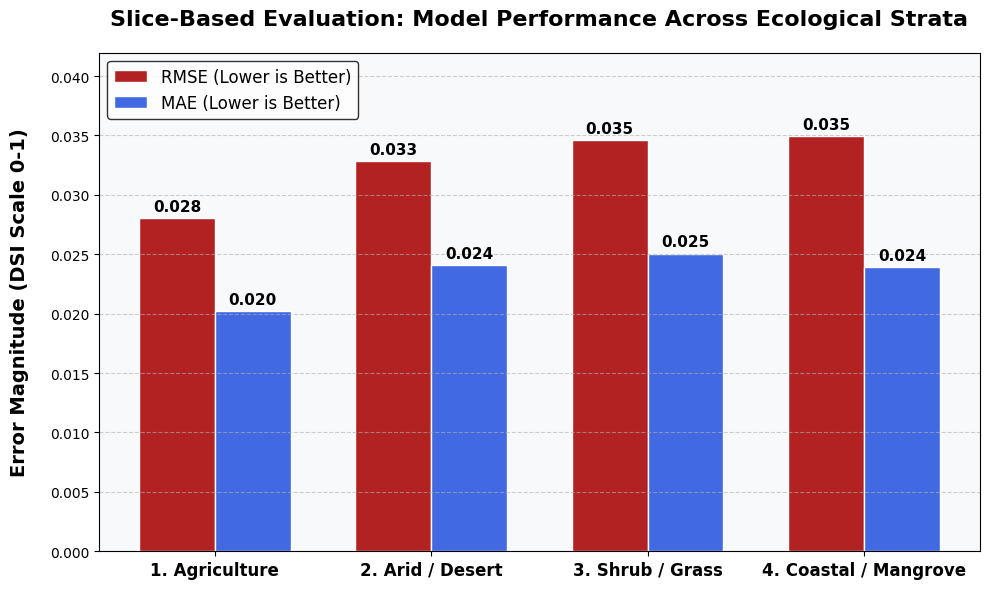

[*] Stratified Bar Chart saved to: /kaggle/working/checkpoints_unet/Stratified_Evaluation_Chart.png


In [28]:
# Run the evaluation
run_stratified_evaluation(TEST_DIR, CHECKPOINT_DIR)

## Perturbation Test

In [56]:
import os
import torch
import numpy as np
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_DIR = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_unet"
NOISE_LEVEL = 0.20 

def run_global_perturbation_test():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Running Global Perturbation Test on: {device}")

    # --- 2. LOAD MODEL & STATS ---
    model = SindhUNet(in_channels=33, base_ch=64).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "unet_best.pth"), map_location=device))
    model.eval()

    global_mean = torch.load(os.path.join(CHECKPOINT_DIR, "unet_mean.pt")).to(device)
    global_std  = torch.load(os.path.join(CHECKPOINT_DIR, "unet_std.pt")).to(device)

    # --- 3. TRACK METRICS ---
    total_abs_diff = 0.0
    total_pixels = 0
    max_diff_global = 0.0

    test_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.pt')]
    
    # --- 4. LOOP THROUGH ENTIRE TEST SET ---
    with torch.no_grad():
        for fname in tqdm(test_files, desc="Perturbing Test Set"):
            patch = torch.load(os.path.join(TEST_DIR, fname), weights_only=True)
            
            # Process all 26 months of the patch at once for speed
            X_raw = patch[:, :33, :, :].to(device)
            
            # Normalize
            X_clean = torch.clamp(X_raw, -100.0, 100.0)
            X_clean = (X_clean - global_mean) / (global_std + 1e-8)
            
            # Predict Clean
            pred_clean = model(X_clean).squeeze(1)
            
            # Inject Noise & Predict
            noise = torch.randn_like(X_clean) * NOISE_LEVEL
            X_noisy = X_clean + noise
            pred_noisy = model(X_noisy).squeeze(1)
            
            # Calculate Differences
            diff_map = torch.abs(pred_clean - pred_noisy)
            
            total_abs_diff += torch.sum(diff_map).item()
            total_pixels += diff_map.numel()
            
            batch_max = torch.max(diff_map).item()
            if batch_max > max_diff_global:
                max_diff_global = batch_max

    # --- 5. FINAL CALCULATION ---
    global_mean_deviation = total_abs_diff / total_pixels

    print("\n" + "=" * 50)
    print(" GLOBAL PERTURBATION TEST RESULTS (ALL PATCHES)")
    print("=" * 50)
    print(f" Total Patches Tested   : {len(test_files)}")
    print(f" Total Pixels Tested    : {total_pixels:,}")
    print(f" Noise Injected         : {int(NOISE_LEVEL*100)}% of Std Dev")
    print(f" Global Mean Deviation  : {global_mean_deviation:.4f}")
    print(f" Global Max Deviation   : {max_diff_global:.4f}")
    print("=" * 50)



In [57]:
run_global_perturbation_test()

[*] Running Global Perturbation Test on: cuda


Perturbing Test Set: 100%|██████████| 500/500 [00:26<00:00, 18.75it/s]


 GLOBAL PERTURBATION TEST RESULTS (ALL PATCHES)
 Total Patches Tested   : 500
 Total Pixels Tested    : 53,248,000
 Noise Injected         : 20% of Std Dev
 Global Mean Deviation  : 0.0066
 Global Max Deviation   : 0.2622


In [54]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
TEST_DIR = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_unet"
SAVE_PERTURB_PATH = os.path.join(CHECKPOINT_DIR, "Perturbation_Robustness_Test.png")

# How much noise to inject? (0.2 = 20% of a standard deviation, which is a massive sensor glitch)
NOISE_LEVEL = 0.20 

def run_perturbation_test(checkpoint_dir):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Running Perturbation Test on: {device}")

    # --- 2. LOAD MODEL & STATS ---
    model = SindhUNet(in_channels=33, base_ch=64).to(device)
    model.load_state_dict(torch.load(os.path.join(checkpoint_dir, "unet_best.pth"), map_location=device))
    model.eval()

    global_mean = torch.load(os.path.join(checkpoint_dir, "unet_mean.pt")).to(device)
    global_std  = torch.load(os.path.join(checkpoint_dir, "unet_std.pt")).to(device)

    # --- 3. GRAB A SINGLE TEST PATCH ---
    # We will just grab the first file we find for the visual
    test_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.pt')]
    sample_file = test_files[170]
    
    print(f"[*] Simulating sensor failure on: {sample_file}")
    patch = torch.load(os.path.join(TEST_DIR, sample_file), weights_only=True)
    
    # Extract just the first month of this patch
    X_raw = patch[0, :33, :, :].unsqueeze(0).to(device) # Shape: (1, 33, 64, 64)
    y_true = patch[0, 37, :, :].cpu().numpy()

    # --- 4. NORMALIZE & PREDICT (CLEAN) ---
    X_clean = torch.clamp(X_raw, -100.0, 100.0)
    X_clean = (X_clean - global_mean) / (global_std + 1e-8)
    
    with torch.no_grad():
        pred_clean = model(X_clean).squeeze().cpu().numpy()

    # --- 5. INJECT NOISE & PREDICT (PERTURBED) ---
    # Generate random Gaussian noise with the same shape as our input
    noise = torch.randn_like(X_clean) * NOISE_LEVEL
    X_noisy = X_clean + noise
    
    with torch.no_grad():
        pred_noisy = model(X_noisy).squeeze().cpu().numpy()

    # Calculate the absolute difference between the two predictions
    diff_map = np.abs(pred_clean - pred_noisy)
    mean_diff = np.mean(diff_map)
    max_diff = np.max(diff_map)

    # --- 6. PLOT THE RESULTS ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
    fig.patch.set_facecolor('#f8f9fa')

    # Shared color map for the predictions
    cmap = plt.get_cmap('RdYlGn_r')
    
    # A. Clean Prediction
    im0 = axes[0].imshow(pred_clean, cmap=cmap, vmin=0, vmax=1)
    axes[0].set_title("1. Clean DSI Prediction", fontsize=14, fontweight='bold')
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # B. Noisy Prediction
    im1 = axes[1].imshow(pred_noisy, cmap=cmap, vmin=0, vmax=1)
    axes[1].set_title(f"2. Perturbed DSI (+{int(NOISE_LEVEL*100)}% Noise)", fontsize=14, fontweight='bold')
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # C. Difference Map
    # We use a 'Reds' colormap here. White = 0 difference, Dark Red = High deviation
    im2 = axes[2].imshow(diff_map, cmap='Reds', vmin=0, vmax=0.1) 
    axes[2].set_title(f"3. Absolute Deviation\n(Mean Error: {mean_diff:.4f})", fontsize=14, fontweight='bold')
    axes[2].axis('off')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.suptitle("Engineering Robustness: Gaussian Noise Perturbation Test", fontsize=20, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(SAVE_PERTURB_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print("\n" + "=" * 50)
    print(" PERTURBATION TEST RESULTS")
    print("=" * 50)
    print(f" Noise Injected     : {int(NOISE_LEVEL*100)}% of Standard Deviation")
    print(f" Mean DSI Deviation : {mean_diff:.4f}")
    print(f" Max DSI Deviation  : {max_diff:.4f}")
    print("=" * 50)

[*] Running Perturbation Test on: cuda
[*] Simulating sensor failure on: Patch_229_Strata_2.pt


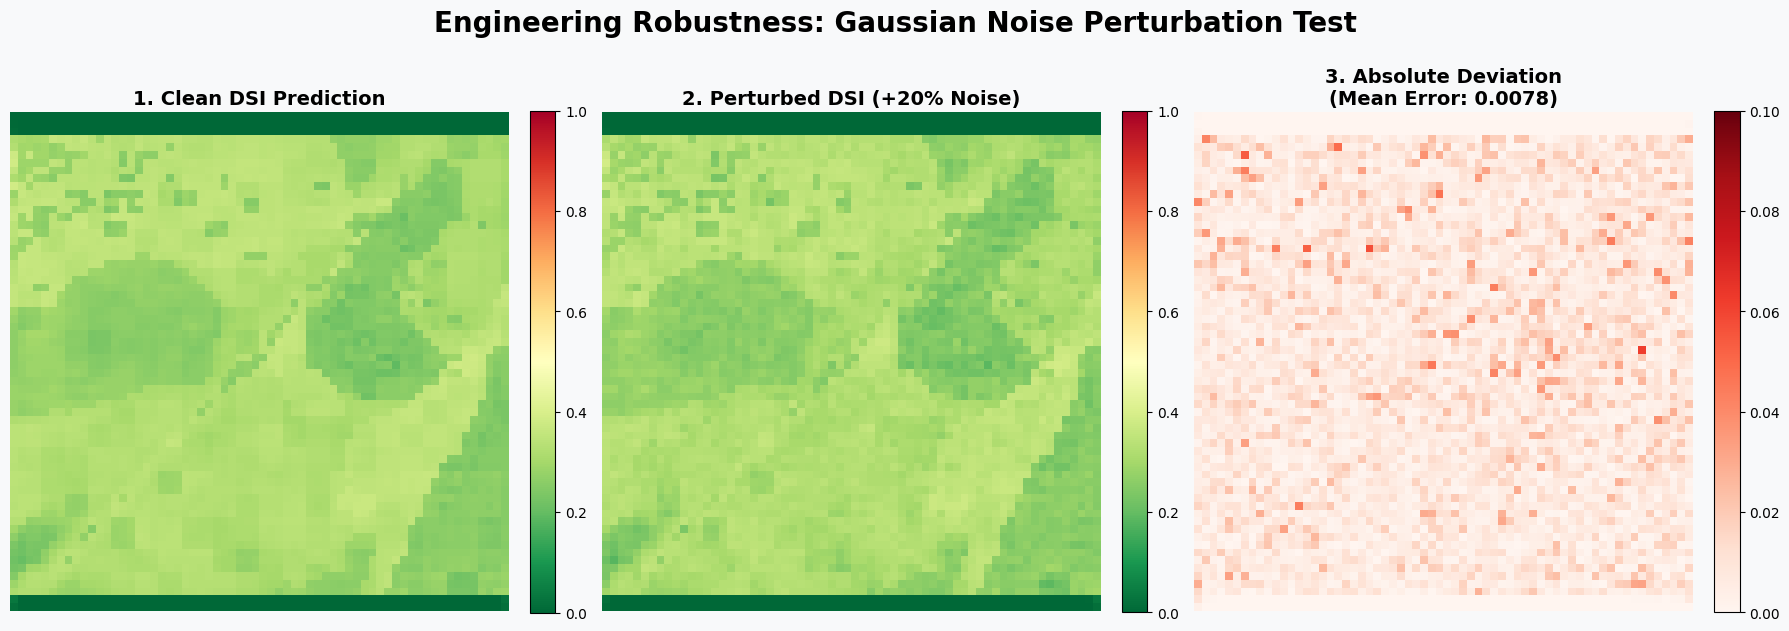


 PERTURBATION TEST RESULTS
 Noise Injected     : 20% of Standard Deviation
 Mean DSI Deviation : 0.0078
 Max DSI Deviation  : 0.0619


In [55]:
# Execute the test
run_perturbation_test(CHECKPOINT_DIR)

## Spatial Residual Mapping

In [60]:
import os
import torch
import numpy as np
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_DIR = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_unet"

def run_global_stratified_residuals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Running Global Stratified Residual Analysis on: {device}")

    # --- 2. LOAD MODEL & STATS ---
    model = SindhUNet(in_channels=33, base_ch=64).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "unet_best.pth"), map_location=device))
    model.eval()

    global_mean = torch.load(os.path.join(CHECKPOINT_DIR, "unet_mean.pt")).to(device)
    global_std  = torch.load(os.path.join(CHECKPOINT_DIR, "unet_std.pt")).to(device)

    # --- 3. TRACKING DICTIONARIES ---
    strata_names = {
        '1': '1. Agriculture',
        '2': '2. Arid / Desert',
        '3': '3. Shrub / Grass',
        '4': '4. Coastal / Mangrove'
    }
    
    # We will track the sum of residuals (pred - true) and total pixels
    metrics = {k: {'residual_sum': 0.0, 'pixel_count': 0} for k in strata_names.keys()}
    global_residual_sum = 0.0
    global_pixel_count = 0

    test_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.pt')]
    
    # --- 4. PROCESS ENTIRE TEST SET ---
    with torch.no_grad():
        for fname in tqdm(test_files, desc="Calculating Residuals"):
            # Parse strata ID
            try:
                strata_id = fname.split('_Strata_')[1].split('.pt')[0]
            except IndexError:
                continue
                
            if strata_id not in metrics:
                continue

            patch = torch.load(os.path.join(TEST_DIR, fname), weights_only=True)
            
            X_raw = patch[:, :33, :, :].to(device)
            y_true = patch[:, 37, :, :].to(device)
            
            # Normalize
            X_clean = torch.clamp(X_raw, -100.0, 100.0)
            X_clean = (X_clean - global_mean) / (global_std + 1e-8)
            
            # Predict
            y_pred = model(X_clean).squeeze(1)
            
            # Calculate Residuals (Pred - True)
            # Positive means Over-predicted, Negative means Under-predicted
            residual_map = y_pred - y_true
            patch_residual_sum = torch.sum(residual_map).item()
            patch_pixels = residual_map.numel()
            
            # Update Strata Metrics
            metrics[strata_id]['residual_sum'] += patch_residual_sum
            metrics[strata_id]['pixel_count'] += patch_pixels
            
            # Update Global Metrics
            global_residual_sum += patch_residual_sum
            global_pixel_count += patch_pixels

    # --- 5. PRINT FINAL RESULTS ---
    print("\n" + "=" * 60)
    print(" STRATIFIED MEAN BIAS (RESIDUAL) RESULTS")
    print("=" * 60)
    
    for k in sorted(strata_names.keys()):
        if metrics[k]['pixel_count'] > 0:
            mean_bias = metrics[k]['residual_sum'] / metrics[k]['pixel_count']
            sign = "+" if mean_bias > 0 else ""
            print(f" {strata_names[k]:<25} | Mean Bias: {sign}{mean_bias:.4f}")
            
    global_mean_bias = global_residual_sum / global_pixel_count
    global_sign = "+" if global_mean_bias > 0 else ""
    
    print("-" * 60)
    print(f" GLOBAL MEAN BIAS (ALL PIXELS) | Mean Bias: {global_sign}{global_mean_bias:.4f}")
    print("=" * 60)
    print(" Note: Positive (+) = Model over-predicts severity")
    print("       Negative (-) = Model under-predicts severity")



In [61]:
run_global_stratified_residuals()

[*] Running Global Stratified Residual Analysis on: cuda


Calculating Residuals: 100%|██████████| 500/500 [00:15<00:00, 31.88it/s]


 STRATIFIED MEAN BIAS (RESIDUAL) RESULTS
 1. Agriculture            | Mean Bias: +0.0168
 2. Arid / Desert          | Mean Bias: +0.0210
 3. Shrub / Grass          | Mean Bias: +0.0228
 4. Coastal / Mangrove     | Mean Bias: +0.0176
------------------------------------------------------------
 GLOBAL MEAN BIAS (ALL PIXELS) | Mean Bias: +0.0194
 Note: Positive (+) = Model over-predicts severity
       Negative (-) = Model under-predicts severity


In [58]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
TEST_DIR = "/kaggle/input/datasets/ahmedfarazshaikh/sindh-desertification-37gb/content/drive/MyDrive/Processed_Sindh_Dataset/test"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_unet"
SAVE_RESIDUAL_PATH = os.path.join(CHECKPOINT_DIR, "Spatial_Residual_Calibration.png")

def run_residual_mapping():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[*] Running Spatial Residual Mapping on: {device}")

    # --- 2. LOAD MODEL & STATS ---
    model = SindhUNet(in_channels=33, base_ch=64).to(device)
    model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "unet_best.pth"), map_location=device))
    model.eval()

    global_mean = torch.load(os.path.join(CHECKPOINT_DIR, "unet_mean.pt")).to(device)
    global_std  = torch.load(os.path.join(CHECKPOINT_DIR, "unet_std.pt")).to(device)

    # --- 3. GRAB A TEST PATCH ---
    # We will grab a patch from the test set (e.g., the 10th file to ensure geographic variety)
    test_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.pt')]
    sample_file = test_files[10] if len(test_files) > 10 else test_files[0]
    
    print(f"[*] Extracting ground truth from: {sample_file}")
    patch = torch.load(os.path.join(TEST_DIR, sample_file), weights_only=True)
    
    # Extract the first month 
    X_raw = patch[0, :33, :, :].unsqueeze(0).to(device)
    y_true = patch[0, 37, :, :].cpu().numpy() # Ground Truth DSI

    # --- 4. PREDICT ---
    X_clean = torch.clamp(X_raw, -100.0, 100.0)
    X_clean = (X_clean - global_mean) / (global_std + 1e-8)
    
    with torch.no_grad():
        y_pred = model(X_clean).squeeze().cpu().numpy()

    # --- 5. CALCULATE RESIDUAL (Pred - True) ---
    residual_map = y_pred - y_true
    
    # Calculate global bias for this patch
    mean_bias = np.mean(residual_map)

    # --- 6. PLOT THE RESULTS ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
    fig.patch.set_facecolor('#f8f9fa')

    # Standard DSI Colormap for the first two maps
    cmap_dsi = plt.get_cmap('RdYlGn_r')
    
    # A. Ground Truth
    im0 = axes[0].imshow(y_true, cmap=cmap_dsi, vmin=0, vmax=1)
    axes[0].set_title("1. Ground Truth DSI (Actual)", fontsize=14, fontweight='bold')
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # B. Prediction
    im1 = axes[1].imshow(y_pred, cmap=cmap_dsi, vmin=0, vmax=1)
    axes[1].set_title("2. Predicted DSI (UNet)", fontsize=14, fontweight='bold')
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # C. Residual Map
    # Diverging colormap: Red = Over-predict, Blue = Under-predict, White = Perfect
    # We lock the scale tightly between -0.1 and +0.1 to force high contrast on tiny errors
    cmap_res = plt.get_cmap('coolwarm')
    im2 = axes[2].imshow(residual_map, cmap=cmap_res, vmin=-0.1, vmax=0.1) 
    
    bias_sign = "+" if mean_bias > 0 else ""
    axes[2].set_title(f"3. Spatial Residual (Pred - True)\n(Mean Bias: {bias_sign}{mean_bias:.4f})", fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    cbar2.set_label('Blue = Under-predicted | Red = Over-predicted', rotation=270, labelpad=20)

    plt.suptitle("Model Calibration: Spatial Residual Analysis", fontsize=20, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(SAVE_RESIDUAL_PATH, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print("\n" + "=" * 50)
    print(" SPATIAL RESIDUAL RESULTS")
    print("=" * 50)
    print(f" Mean Bias (Overall Drift) : {bias_sign}{mean_bias:.4f}")
    print(f" Max Over-prediction       : +{np.max(residual_map):.4f}")
    print(f" Max Under-prediction      : {np.min(residual_map):.4f}")
    print("=" * 50)

[*] Running Spatial Residual Mapping on: cuda
[*] Extracting ground truth from: Patch_165_Strata_2.pt


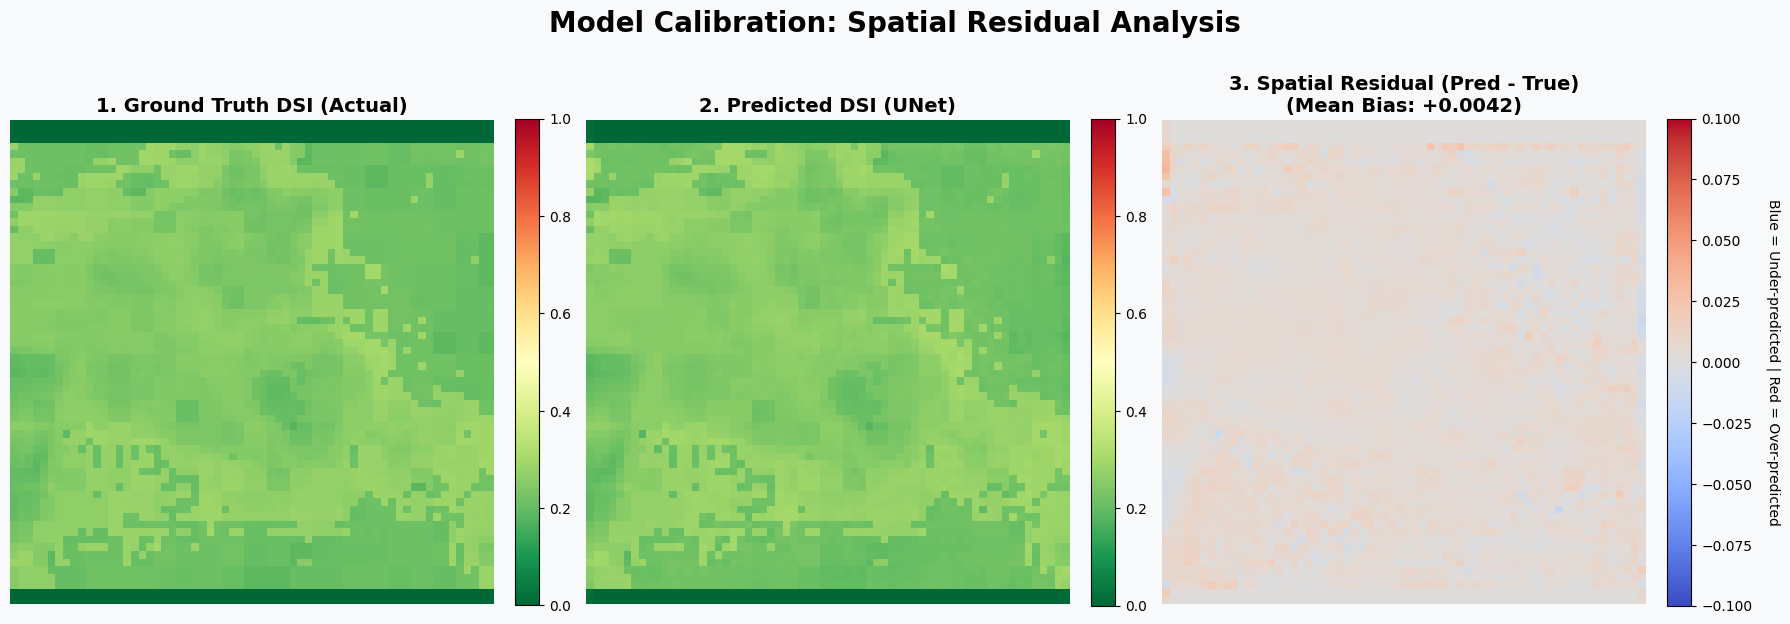


 SPATIAL RESIDUAL RESULTS
 Mean Bias (Overall Drift) : +0.0042
 Max Over-prediction       : +0.0341
 Max Under-prediction      : -0.0160


In [59]:
run_residual_mapping()